In [1]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [6]:
import os
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
import gzip

from segmentation_functions import plot_licks_PSTH, plot_whisker_psth, plot_paw_hist, plot_paw_choice_psth, plot_wheel_choicepsth, plot_paw_left_feedbackpsth, plot_paw_right_feedbackpsth

from one.api import ONE
one = ONE(mode='remote')

In [3]:
""" Load BWM data post-QC """
gdrive_path = "/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/"
filename = '1_bwm_qc_04-26-2026'
bwm_query = pickle.load(gzip.open(gdrive_path+filename, "rb"))

In [4]:
# Loop through animals
sessions = bwm_query['eid'].unique()
data_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/design_matrices/'

os.chdir(data_path)
files = os.listdir()
sessions_to_process = []

for s, sess in enumerate(sessions):
    file_path = one.eid2path(sess)

    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    filename = "design_matrix_" + str(sess) + '_'  + mouse_name
    if filename in files:
        sessions_to_process.append((sess))

len(sessions_to_process)

318

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/Users/ineslaranjeira/.gemini/antigravity/scratch/representation_learning_variability/pipeline_manual/segmentation/segmentation_functions.py:170: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


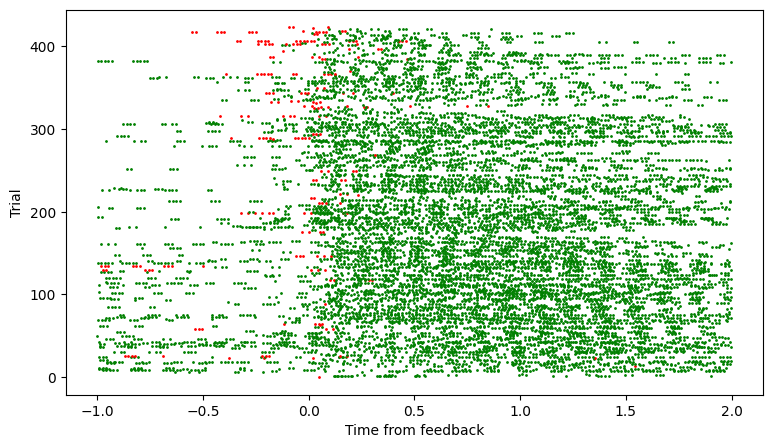

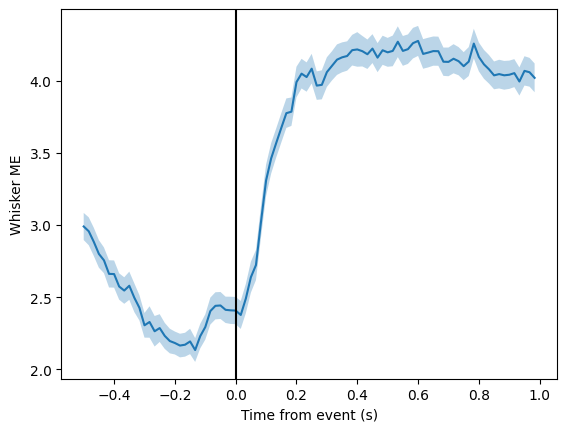

/Users/ineslaranjeira/.gemini/antigravity/scratch/representation_learning_variability/pipeline_manual/segmentation/segmentation_functions.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/ineslaranjeira/.gemini/antigravity/scratch/representation_learning_variability/pipeline_manual/segmentation/segmentation_functions.py:305: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(str(save_path + mat + '_paw_hist.png'), format='png')
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


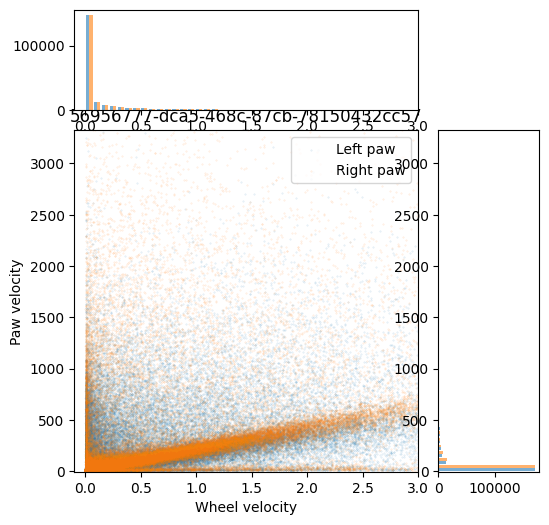

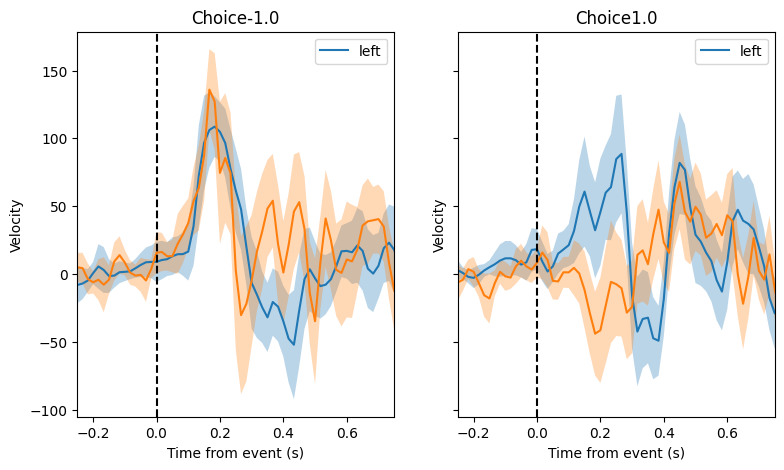

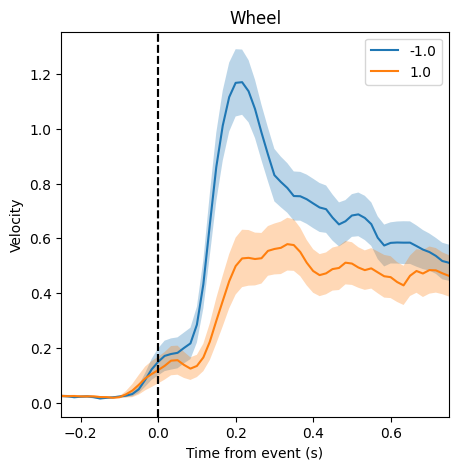

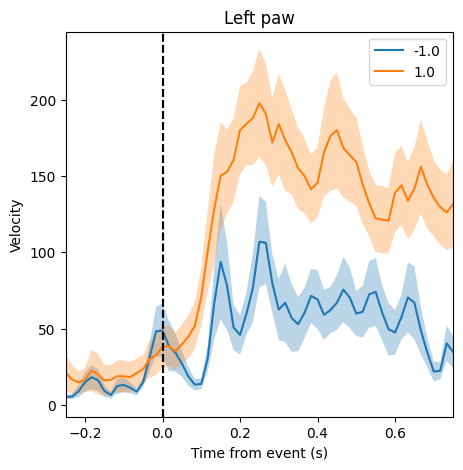

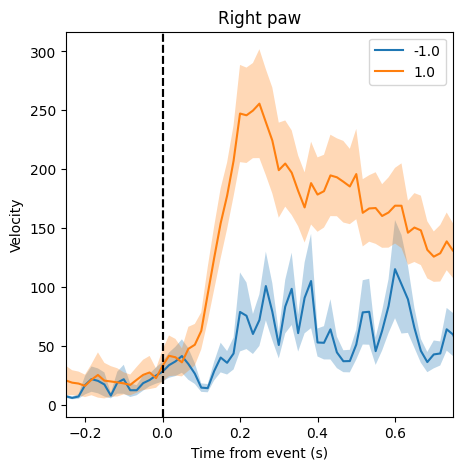

56956777-dca5-468c-87cb-78150432cc57


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/Users/ineslaranjeira/.gemini/antigravity/scratch/representation_learning_variability/pipeline_manual/segmentation/segmentation_functions.py:170: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  licks_df = pd.concat([licks_df, temp_df])


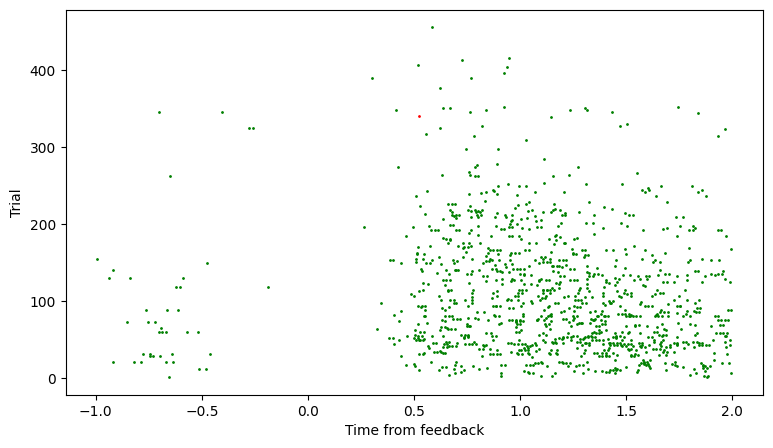

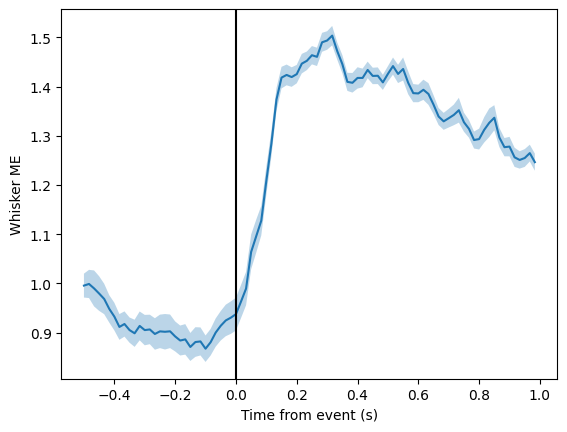

/Users/ineslaranjeira/.gemini/antigravity/scratch/representation_learning_variability/pipeline_manual/segmentation/segmentation_functions.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/ineslaranjeira/.gemini/antigravity/scratch/representation_learning_variability/pipeline_manual/segmentation/segmentation_functions.py:305: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(str(save_path + mat + '_paw_hist.png'), format='png')
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


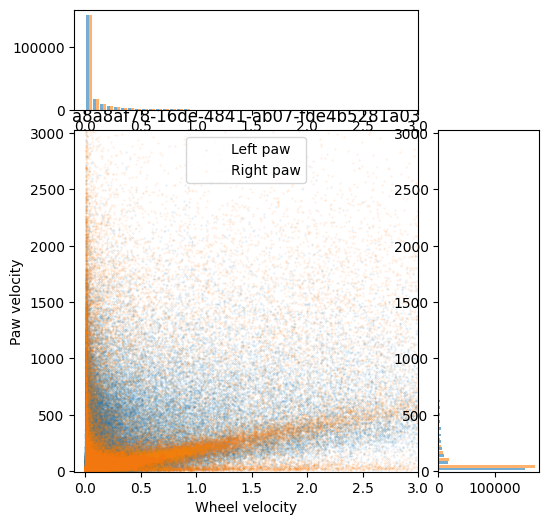

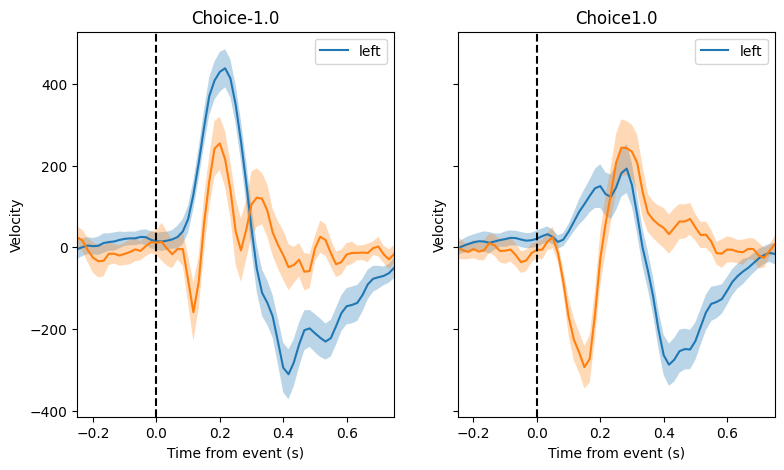

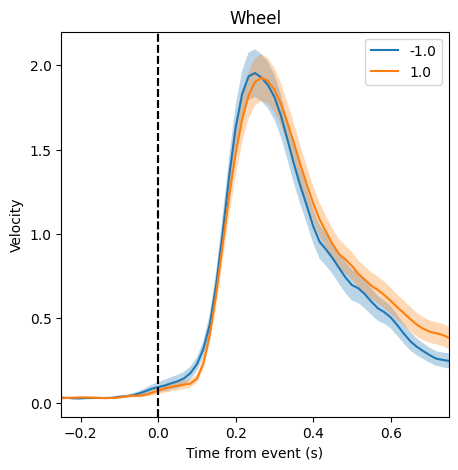

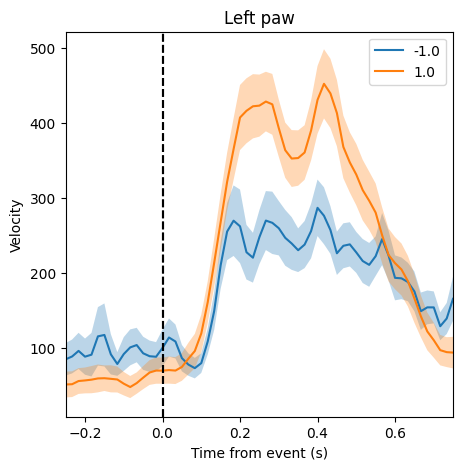

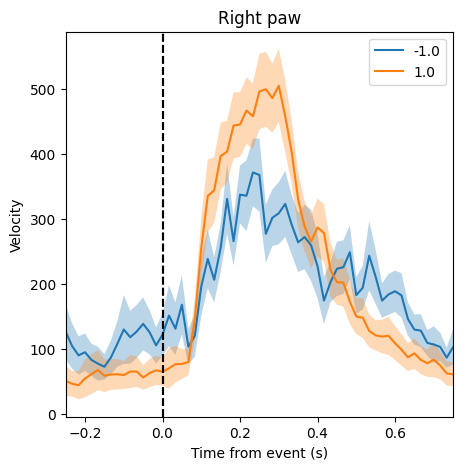

a8a8af78-16de-4841-ab07-fde4b5281a03


In [7]:
results_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/qc_inspection/'

for m, mat in enumerate(sessions_to_process[:2]):

    file_path = one.eid2path(mat)
    if prefix == '/home/ines/repositories/':
        mouse_name = file_path.parts[8]
    else:
        mouse_name = file_path.parts[7]

    session = mat
    filename = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    # Get trials for corresponding session
    trials = one.load_object(mat, obj='trials', namespace='ibl')
    trial_df = trials.to_df()

    # Licking
    lick_times = np.array(design_matrix.loc[design_matrix['Lick count']==1, 'Bin'])
    plot_licks_PSTH(mat, trial_df, lick_times, results_path)

    # Whisking
    plot_whisker_psth(mat, design_matrix, trial_df, 'stimOn_times', results_path)

    # Paws
    plot_paw_hist(mat, design_matrix, results_path)
    plot_paw_choice_psth(mat, design_matrix, trial_df, results_path)
    plot_wheel_choicepsth(mat, design_matrix, trial_df, results_path)
    plot_paw_left_feedbackpsth(mat, design_matrix, trial_df, results_path)
    plot_paw_right_feedbackpsth(mat, design_matrix, trial_df, results_path)
    print(mat)
